# RESUM_FLEX — Minimal End-to-End Example

This notebook walks through the **full pipeline** on synthetic data:

1. Load a YAML config
2. Generate pseudo data with a known ground truth `t(θ, φ)`
3. Train the **CNP** to recover the continuous score `β ≈ p` from binary `X`
4. Fit the **3-fidelity MFGP** on `(LF β̄, HF β̄, HF y_raw)`
5. Check held-out coverage (68 / 95 / 99.7 % target)
6. Run a short **IVR active-learning loop** to pick the next θ to simulate

Everything runs on CPU in ~1–2 minutes with the notebook-friendly
`config_minimal.yaml`. For paper-quality reconstructions, swap to the
canonical `../config.yaml`.

> **Background.** RESUM_FLEX solves the *Rare Event Design (RED)* problem
> from the [RESuM paper](https://openreview.net/pdf?id=lqTILjL6lP). The
> design metric `y = m/N` is a discrete count with high variance; the CNP
> denoises it event-by-event, the MFGP fuses fidelity tiers, and the IVR
> acquisition picks the next design point. See `../CLAUDE.md` for the
> full math reference.

## 0. Setup

Add the repo root to `sys.path` so the notebook can import the package
without a `pip install -e .` step (and seed RNGs for reproducibility).

In [1]:
import sys
from pathlib import Path

# Make the project root importable: notebooks/ is one level below the root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

print(f"Repo root: {REPO_ROOT}")
print(f"torch:     {torch.__version__}")
print(f"numpy:     {np.__version__}")

Repo root: /home/yuema137/RESUM_FLEX
torch:     2.11.0+cpu
numpy:     1.26.4


## 1. Load the configuration

Every hyperparameter (encoder widths, CNP context window, training steps,
MFGP kernel, IVR MC samples, per-scenario MAE thresholds) lives in one
YAML file and is validated against the pydantic models in
`schemas/config.py`. We ship a notebook-friendly file alongside the
notebook — it's the same schema as the repo's `config.yaml`, just with
fewer training steps for speed.

In [2]:
from schemas.config import load_config

cfg = load_config(REPO_ROOT / "notebooks" / "config_minimal.yaml")

print(f"encoder.latent_dim       = {cfg.encoder.latent_dim}")
print(f"cnp.n_context_min/max    = {cfg.cnp.n_context_min} .. {cfg.cnp.n_context_max}")
print(f"training.n_steps         = {cfg.training.n_steps}")
print(f"training.batch_size      = {cfg.training.batch_size}")
print(f"mfgp.kernel              = {cfg.mfgp.kernel}")
print(f"ivr.n_mc_samples         = {cfg.ivr.n_mc_samples}")
print(f"mae_thresholds.s1        = {cfg.mae_thresholds.s1}")

encoder.latent_dim       = 32
cnp.n_context_min/max    = 32 .. 96
training.n_steps         = 500
training.batch_size      = 16
mfgp.kernel              = rbf
ivr.n_mc_samples         = 500
mae_thresholds.s1        = 0.05


## 2. Generate pseudo data

`PseudoDataGenerator` wraps an analytical truth `t(θ, φ) ∈ [0, 1]` and
samples binary outcomes `X ~ Bernoulli(t)` from it. Eight canonical
scenarios (`S1..S8`) cover every combination of input modality (`FULL`,
`EVENT_ONLY`, `DESIGN_ONLY`) and `dim(θ), dim(φ) ∈ {1, 2}`. We use **S1**
(FULL, 1D θ, 1D φ, Gaussian bump truth) for this minimal example because
it's the easiest to visualize end-to-end.

The generator returns a `StandardBatch` — the typed data carrier consumed
by every downstream module.

In [3]:
from data.pseudo_generator import for_scenario

generator = for_scenario("S1", seed=0)

# Draw one batch so we can inspect its shapes.
batch = generator.generate(n_trials=4, n_events=8, seed=0)
print(f"mode         : {batch.mode.value}")
print(f"theta shape  : {batch.theta.shape}   # (B, D_theta)")
print(f"phi shape    : {batch.phi.shape} # (B, N, D_phi)")
print(f"labels shape : {batch.labels.shape} # (B, N), values in {{0, 1}}")
print(f"labels sample: {batch.labels[0]}")
print(f"\nAnalytical truth peak: theta_peak={generator.truth.theta_peak}, "
      f"phi_peak={generator.truth.phi_peak}, t_max={generator.truth.t_max}")

mode         : full
theta shape  : (4, 1)   # (B, D_theta)
phi shape    : (4, 8, 1) # (B, N, D_phi)
labels shape : (4, 8) # (B, N), values in {0, 1}
labels sample: [0 0 0 0 0 0 0 0]

Analytical truth peak: theta_peak=[0.2], phi_peak=[-0.2], t_max=0.4


## 3. Visualize the ground truth

Before training anything, look at the analytical surface we're trying to
recover. For S1 (1D θ, 1D φ) this is a 2D heatmap of `p(θ, φ)`.

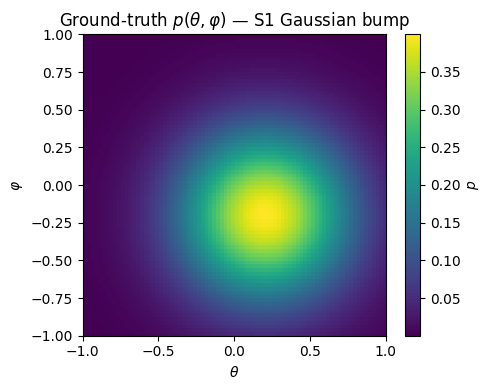

In [4]:
theta_axis = np.linspace(-1.0, 1.0, 80)
phi_axis = np.linspace(-1.0, 1.0, 80)
TH, PH = np.meshgrid(theta_axis, phi_axis, indexing="ij")
p_truth = generator.truth.evaluate(
    theta=TH[..., None], phi=PH[..., None],
)  # shape (80, 80)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    p_truth.T, origin="lower", extent=[-1, 1, -1, 1], aspect="auto", cmap="viridis",
)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$\varphi$")
ax.set_title(r"Ground-truth $p(\theta, \varphi)$ — S1 Gaussian bump")
fig.colorbar(im, ax=ax, label=r"$p$")
plt.tight_layout(); plt.show()

## 4. Build and train the CNP

The Conditional Neural Process takes `(θ, φ_i, X_i)` context points,
aggregates them across the **event axis** (never the batch axis), and
predicts a continuous score `β ≈ p` per target event.

**Key training details** (defined in `core/training.py`):

- Each step samples a fresh batch and a random `n_context` in
  `[n_context_min, n_context_max]` (the meta-learning paradigm).
- The configured `theory-truth` objective is the marginalized Bernoulli NLL;
  use `practice-truth` only to reproduce the legacy Normal-on-X code.
- Periodically, MAE(β, p) is computed against the analytical truth (only
  possible because this is synthetic data; disable on real data with
  `eval_every=0`).

In [5]:
from core import build_cnp, train_cnp

cnp = build_cnp(
    cfg.encoder,
    dim_theta=generator.dim_theta,
    dim_phi=generator.dim_phi,
)
n_params = sum(p.numel() for p in cnp.parameters())
print(f"CNP built with {n_params:,} parameters")

history = train_cnp(
    cnp, generator,
    cnp_config=cfg.cnp,
    training_config=cfg.training,
)

print(f"\nFinal training loss: {history['loss'][-1]:.4f}")
if history["eval_mae"]:
    print(f"Last in-loop MAE(β, p): {history['eval_mae'][-1]:.4f}")

CNP built with 31,714 parameters

Final training loss: 0.2763
Last in-loop MAE(β, p): 0.0119


### Training curves

Loss should decrease monotonically; in-loop MAE(β, p) should drop below
the per-scenario threshold from the config (`mae_thresholds.s1 = 0.05`).

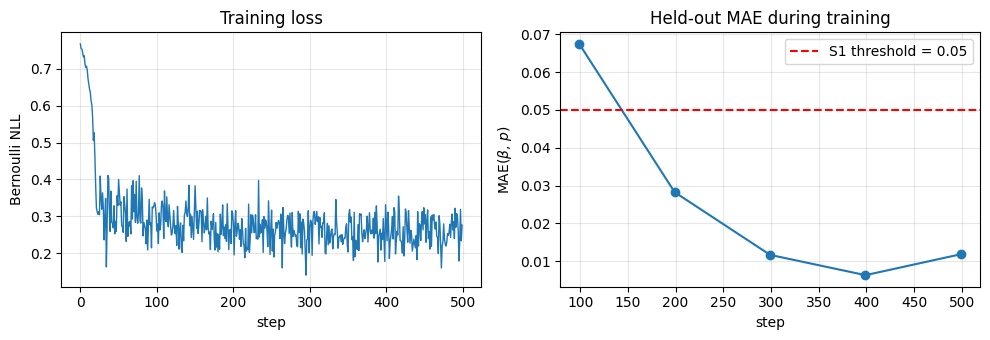

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))

ax0.plot(history["step"], history["loss"], lw=1.0)
ax0.set_xlabel("step"); ax0.set_ylabel(cfg.cnp.objective); ax0.set_title("Training loss")
ax0.grid(alpha=0.3)

if history["eval_mae"]:
    ax1.plot(history["eval_step"], history["eval_mae"], marker="o")
    ax1.axhline(cfg.mae_thresholds.s1, color="red", linestyle="--",
                label=f"S1 threshold = {cfg.mae_thresholds.s1}")
    ax1.set_xlabel("step"); ax1.set_ylabel(r"MAE($\beta$, $p$)")
    ax1.set_title("Held-out MAE during training"); ax1.legend(); ax1.grid(alpha=0.3)
else:
    ax1.text(0.5, 0.5, "no eval (eval_every=0)", ha="center", va="center")

plt.tight_layout(); plt.show()

## 5. Visualize CNP reconstruction

The acceptance test for Phase 3 is that the **predicted `β` heatmap peak
lines up with the ground-truth `p` peak**. We sample a fresh evaluation
batch on a dense grid and let the CNP predict `β` for every grid point,
then overlay the two heatmaps side-by-side with a shared color scale.

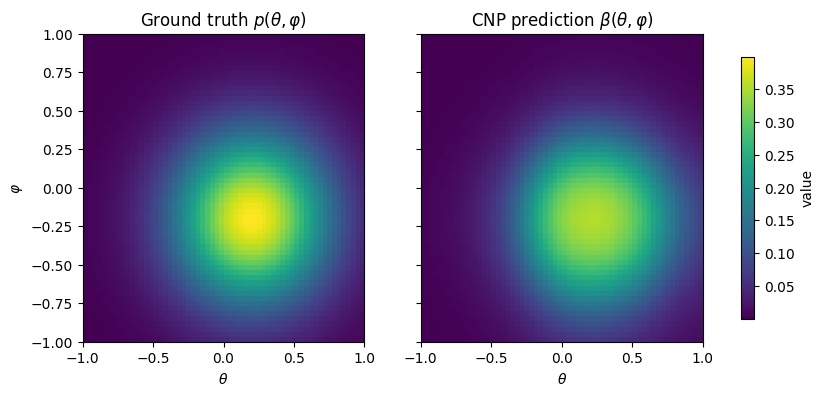

MAE(β, p) on the grid: 0.0104   (threshold = 0.05)


In [7]:
from schemas.data_models import InputMode, StandardBatch

cnp.eval()

# Build a (theta, phi) grid for the reconstruction heatmap.
N_GRID = 60
theta_grid = np.linspace(-1.0, 1.0, N_GRID)
phi_grid = np.linspace(-1.0, 1.0, N_GRID)
TG, PG = np.meshgrid(theta_grid, phi_grid, indexing="ij")

# Ground truth on this exact grid (so MAE compares like-for-like).
p_truth_grid = generator.truth.evaluate(
    theta=TG[..., None], phi=PG[..., None],
)  # (N_GRID, N_GRID)

# Build one trial per theta_grid value. The context events for trial i are
# sampled from p(theta_grid[i], phi) so labels are consistent with theta.
rng = np.random.default_rng(123)
n_ctx_events = 64
phi_ctx = rng.uniform(-1.0, 1.0, size=(N_GRID, n_ctx_events, 1))
p_ctx = generator.truth.evaluate(
    theta=theta_grid.reshape(-1, 1, 1), phi=phi_ctx,
)  # (N_GRID, n_ctx_events)
labels_ctx = (rng.uniform(size=p_ctx.shape) < p_ctx).astype(np.int8)

ctx_batch = StandardBatch(
    mode=InputMode.FULL,
    theta=theta_grid.reshape(-1, 1),
    phi=phi_ctx,
    labels=labels_ctx,
)

# Targets share each trial's theta but probe every phi on the grid.
phi_target = np.broadcast_to(phi_grid.reshape(1, -1, 1), (N_GRID, N_GRID, 1)).copy()
target_batch = StandardBatch(
    mode=InputMode.FULL,
    theta=theta_grid.reshape(-1, 1),
    phi=phi_target,
    labels=np.zeros((N_GRID, N_GRID), dtype=np.int8),  # ignored at predict time
)

with torch.no_grad():
    beta_pred = cnp.predict_beta(ctx_batch, target_batch).cpu().numpy()  # (N_GRID, N_GRID)

vmin = min(p_truth_grid.min(), beta_pred.min())
vmax = max(p_truth_grid.max(), beta_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, field, title in zip(
    axes,
    [p_truth_grid, beta_pred],
    [r"Ground truth $p(\theta, \varphi)$", r"CNP prediction $\beta(\theta, \varphi)$"],
):
    im = ax.imshow(field.T, origin="lower", extent=[-1, 1, -1, 1],
                   aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xlabel(r"$\theta$"); ax.set_title(title)
axes[0].set_ylabel(r"$\varphi$")
fig.colorbar(im, ax=axes, shrink=0.85, label="value")
plt.show()

mae = float(np.abs(beta_pred - p_truth_grid).mean())
print(f"MAE(β, p) on the grid: {mae:.4f}   (threshold = {cfg.mae_thresholds.s1})")

## 6. Fit the 3-fidelity MFGP

The MFGP fuses three datasets keyed by θ:

1. **LF β̄** — cheap, broad coverage: many trials, few events each.
2. **HF β̄** — same metric on high-fidelity trials.
3. **HF y_raw = m/N** — the ultimate target signal.

Co-kriging (Kennedy–O'Hagan recursion) couples them via
`f_H(θ) = ρ·f_L(θ) + δ(θ)`. The helper `prepare_mfgp_datasets` does the
CNP aggregation + dataset packing for synthetic data; for real data you'd
call `prepare_mfgp_datasets_from_batches` with your own `StandardBatch`es.

In [8]:
from core import fit_mfgp_three_fidelity, prepare_mfgp_datasets

data = prepare_mfgp_datasets(
    cnp, generator,
    n_lf_trials=80, n_lf_events=64,    # many cheap trials
    n_hf_trials=8,  n_hf_events=128,   # few expensive trials
    n_mc_samples=50,
    seed=0,
)
for k, v in data.items():
    print(f"{k:10s}  shape={v.shape}")

mfgp = fit_mfgp_three_fidelity(data, config=cfg.mfgp, n_restarts=3)
print(f"\nMFGP fitted: dim_theta={mfgp.dim_theta}, fidelities={mfgp.n_fidelities}")

X_lf        shape=(80, 1)
Y_lf_cnp    shape=(80, 1)
X_hf        shape=(8, 1)
Y_hf_cnp    shape=(8, 1)
Y_hf_raw    shape=(8, 1)

MFGP fitted: dim_theta=1, fidelities=3


### MFGP posterior — 1D slice

Plot the MFGP posterior mean ± 1σ across θ and compare against the
**marginalized truth** `t̄(θ) = ∫ t(θ, φ) g(φ) dφ`. Since φ ~ U(−1, 1),
`g(φ) = 1/2`, so we evaluate `t̄(θ)` by averaging the analytical truth
over a fine φ-grid.

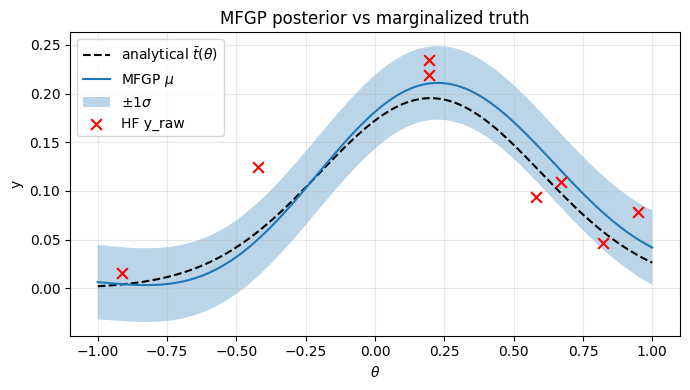

In [9]:
theta_query = np.linspace(-1.0, 1.0, 100).reshape(-1, 1)
mu, var = mfgp.predict(theta_query)
sigma = np.sqrt(var)

# Marginalized analytical truth: integrate p(theta, phi) over phi ~ U(-1, 1).
phi_mc = np.linspace(-1.0, 1.0, 400).reshape(-1, 1)
t_bar = np.array([
    generator.truth.evaluate(theta=np.array([[t]]), phi=phi_mc).mean()
    for t in theta_query.ravel()
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_query.ravel(), t_bar, "k--", label=r"analytical $\bar t(\theta)$")
ax.plot(theta_query.ravel(), mu, "C0-", label=r"MFGP $\mu$")
ax.fill_between(theta_query.ravel(), mu - sigma, mu + sigma, alpha=0.3, label=r"$\pm 1\sigma$")
ax.scatter(data["X_hf"].ravel(), data["Y_hf_raw"].ravel(),
           color="red", marker="x", s=60, label="HF y_raw", zorder=5)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("y")
ax.set_title("MFGP posterior vs marginalized truth")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Held-out coverage check

Generate a fresh batch the MFGP has never seen, and check what fraction
of observed `y_raw = m/N` values fall inside the posterior ±kσ bands.
Targets: 68.27 / 95.45 / 99.73 %.

In [10]:
from core import evaluate_mfgp_coverage

coverage = evaluate_mfgp_coverage(
    mfgp, cnp, generator,
    n_test_trials=60, n_test_events=128, seed=12345,
)
print(f"±1σ coverage: {coverage['1sigma']:.1%}  (target 68.3%)")
print(f"±2σ coverage: {coverage['2sigma']:.1%}  (target 95.5%)")
print(f"±3σ coverage: {coverage['3sigma']:.1%}  (target 99.7%)")

±1σ coverage: 68.3%  (target 68.3%)
±2σ coverage: 91.7%  (target 95.5%)
±3σ coverage: 100.0%  (target 99.7%)


## 8. Active learning with IVR

Given the fitted MFGP, IVR (Integrated Variance Reduction) picks the next
design point that — if observed at the highest fidelity — maximally
shrinks `∫Θ σ²(θ) dθ`. Each step queries the pseudo-truth at the chosen
θ, appends one new HF observation, refits the MFGP, and records the
integrated variance before/after.

We run 3 steps here to keep the notebook quick; the canonical demo runs
5 (see `scripts/phase5_plot_optimizer.py`).

In [11]:
from core import ActiveLearningLoop, BoxBounds

bounds = BoxBounds(low=np.array([-1.0]), high=np.array([1.0]))

loop = ActiveLearningLoop(
    mfgp=mfgp, generator=generator, cnp=cnp,
    bounds=bounds, data=data,
    n_hf_events=128,
    n_mc_samples=cfg.ivr.n_mc_samples,
    n_candidates_per_axis=80,
    refit_n_restarts=3,
    acquisition="ivr",
    seed=0,
)
records = loop.run(n_steps=3)

print(f"{'step':>4} {'theta_next':>12} {'IV before':>12} {'IV after':>12}  shrunk?")
for rec in records:
    print(f"{rec.step:>4} {rec.theta_next[0]:>12.3f} "
          f"{rec.integrated_variance_before:>12.3e} "
          f"{rec.integrated_variance_after:>12.3e}  "
          f"{'yes' if rec.integrated_variance_after < rec.integrated_variance_before else 'no'}")

step   theta_next    IV before     IV after  shrunk?
   0       -1.000    2.860e-03    2.548e-03  yes
   1       -0.671    2.548e-03    2.356e-03  yes
   2        1.000    2.356e-03    2.470e-03  no


### Visualize the AL trajectory

Plot the MFGP posterior **after** the final AL step, overlay the
original HF observations (grey) and the new AL-picked points (red stars)
with their step number. The posterior should hug the analytical truth
more tightly where AL stars cluster.

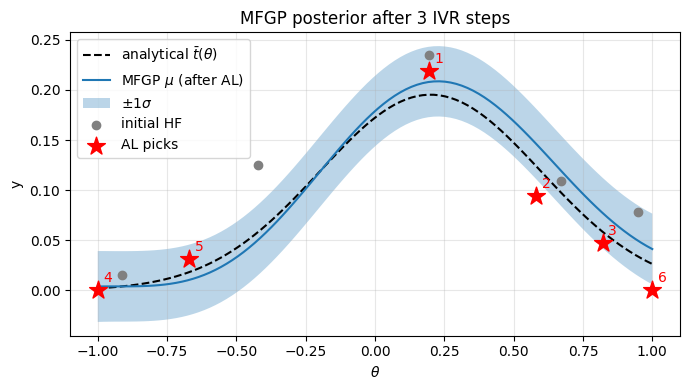

In [12]:
mu_final, var_final = loop.mfgp.predict(theta_query)
sigma_final = np.sqrt(var_final)

n_initial_hf = data["X_hf"].shape[0] - len(records)
x_hf_all = loop.data["X_hf"].ravel()
y_hf_all = loop.data["Y_hf_raw"].ravel()
x_initial, y_initial = x_hf_all[:n_initial_hf], y_hf_all[:n_initial_hf]
x_al, y_al = x_hf_all[n_initial_hf:], y_hf_all[n_initial_hf:]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_query.ravel(), t_bar, "k--", label=r"analytical $\bar t(\theta)$")
ax.plot(theta_query.ravel(), mu_final, "C0-", label=r"MFGP $\mu$ (after AL)")
ax.fill_between(theta_query.ravel(), mu_final - sigma_final, mu_final + sigma_final,
                alpha=0.3, label=r"$\pm 1\sigma$")
ax.scatter(x_initial, y_initial, c="gray", marker="o", label="initial HF", zorder=4)
ax.scatter(x_al, y_al, c="red", marker="*", s=180, label="AL picks", zorder=5)
for i, (xi, yi) in enumerate(zip(x_al, y_al), start=1):
    ax.annotate(str(i), (xi, yi), xytext=(4, 6), textcoords="offset points", color="red")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("y")
ax.set_title("MFGP posterior after 3 IVR steps")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Wrap-up

You just ran the full RESUM_FLEX pipeline:

- **CNP** denoised binary `X` into continuous `β ≈ p` (MAE within the S1
  threshold from the config).
- **MFGP** fused LF / HF β̄ with HF y_raw and produced a posterior that
  tracks the marginalized truth `t̄(θ)`.
- **IVR** picked new θ to simulate; integrated variance shrank after each
  refit.

### Where to go next

- **Other scenarios.** Swap `for_scenario("S1")` for any of `S2..S8` to
  cover 2D θ, 2D φ, EVENT_ONLY, or DESIGN_ONLY modalities.
- **Real data.** Replace `PseudoDataGenerator` with a `BatchSampler`-style
  adapter that resamples from your own `StandardBatch`. See README
  §Usage — step 2 for a working template.
- **Production config.** Switch from `config_minimal.yaml` to the repo's
  `config.yaml` (1500 training steps, full latent dims) for paper-quality
  reconstructions.
- **Active-learning variants.** Swap `acquisition="ivr"` for
  `"ei"` with `target="min"` / `"max"` to optimize toward an extremum
  instead of pure exploration.
- **Save / reload.** `save_checkpoint(...)` for the CNP and
  `save_mfgp(...)` for the GP — see README §Usage — step 7.